#📌 Extracción

In [ ]:
#importando las librerias
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

telecom_x_data = pd.read_json('https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json')
telecom_x_data

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
...,...,...,...,...,...,...
7262,9987-LUTYD,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
7263,9992-RRAMN,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7264,9992-UJOEL,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7265,9993-LHIEB,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Two year', 'PaperlessBilling': '..."


#🔧 Transformación

In [ ]:
#explorando tipos de datos de columans
# Ver las primeras filas
telecom_x_data.head()
# Información general del dataset
telecom_x_data.info()
# Estadísticas descriptivas de las variables numéricas
telecom_x_data.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


,customerID,Churn,customer,phone,internet,account
count,7267,7267,7267,7267,7267,7267
unique,7267,3,891,3,129,6931
top,9995-HOTOH,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'No', 'OnlineSecurity': 'N...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
freq,1,5174,223,3495,1581,6


In [ ]:
df_customer = pd.json_normalize(telecom_x_data['customer'])
df_phone = pd.json_normalize(telecom_x_data['phone'])
df_internet = pd.json_normalize(telecom_x_data['internet'])
df_account = pd.json_normalize(telecom_x_data['account'])

df_telecom = pd.concat([
    telecom_x_data[['customerID', 'Churn']],
    df_customer,
    df_phone,
    df_internet,
    df_account
    ], axis=1)

In [ ]:
#nulos
df_telecom.isnull().sum()

#duplicados
df_telecom.duplicated().sum()

# errores de formato
for col in ['MonthlyCharges', 'TotalCharges']:
    if col in df_telecom.columns:
        df_telecom[col] = pd.to_numeric(df_telecom[col], errors='coerce')

#Inconsistencias en categorías
for col in df_telecom.select_dtypes(include=['object']).columns:
    print(f"{col}: {df_telecom[col].unique()[:10]}")

customerID: ['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' '0011-IGKFF' '0013-EXCHZ'
 '0013-MHZWF' '0013-SMEOE' '0014-BMAQU' '0015-UOCOJ' '0016-QLJIS']
Churn: ['No' 'Yes' '']
gender: ['Female' 'Male']
Partner: ['Yes' 'No']
Dependents: ['Yes' 'No']
PhoneService: ['Yes' 'No']
MultipleLines: ['No' 'Yes' 'No phone service']
InternetService: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: ['No' 'Yes' 'No internet service']
OnlineBackup: ['Yes' 'No' 'No internet service']
DeviceProtection: ['No' 'Yes' 'No internet service']
TechSupport: ['Yes' 'No' 'No internet service']
StreamingTV: ['Yes' 'No' 'No internet service']
StreamingMovies: ['No' 'Yes' 'No internet service']
Contract: ['One year' 'Month-to-month' 'Two year']
PaperlessBilling: ['Yes' 'No']
PaymentMethod: ['Mailed check' 'Electronic check' 'Credit card (automatic)'
 'Bank transfer (automatic)']
Charges.Total: ['593.3' '542.4' '280.85' '1237.85' '267.4' '571.45' '7904.25' '5377.8'
 '340.35' '5957.9']


In [ ]:
#tratamiento
# Normalizar strings
for col in df_telecom.select_dtypes(include=['object']).columns:
    df_telecom[col] = df_telecom[col].str.lower().str.strip()

# Homogeneizar valores
if 'Churn' in df_telecom.columns:
    df_telecom['Churn'] = df_telecom['Churn'].replace({'yes':'si', 'no':'no'})

# Eliminar duplicados
df_telecom = df_telecom.drop_duplicates()

# Imputar nulos en columnas numéricas con 0
for col in df_telecom.select_dtypes(include=['float','int']).columns:
    df_telecom[col] = df_telecom[col].fillna(0)


#📊 Carga y análisis

In [ ]:
# Métricas descriptivas
df_telecom.describe()

# Mediana y desviación estándar
df_telecom.median(numeric_only=True)
df_telecom.std(numeric_only=True)


,0
SeniorCitizen,0.369074
tenure,24.571773
Charges.Monthly,30.129572


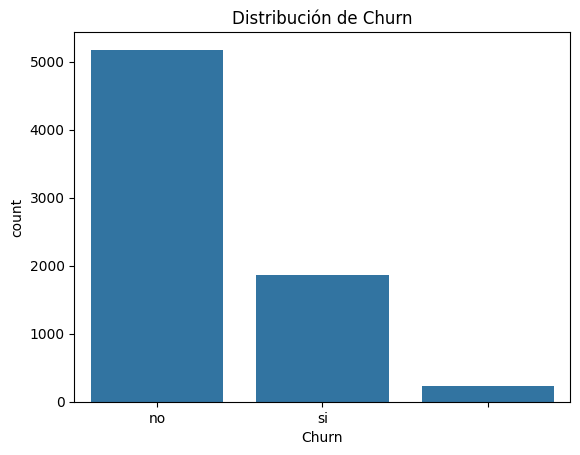

In [ ]:
#distribucion de churn
sns.countplot(x='Churn', data=df_telecom)
plt.title("Distribución de Churn")
plt.show()

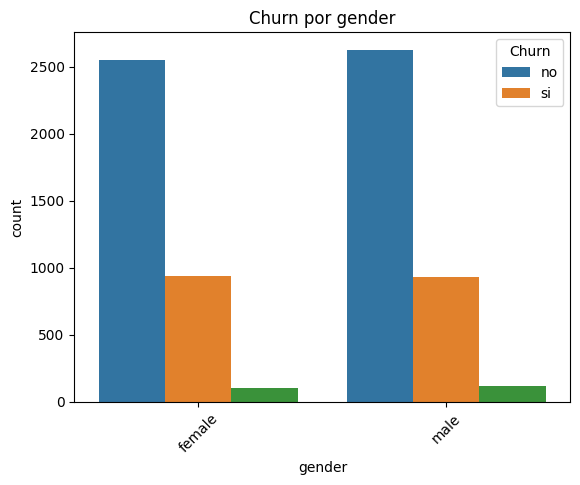

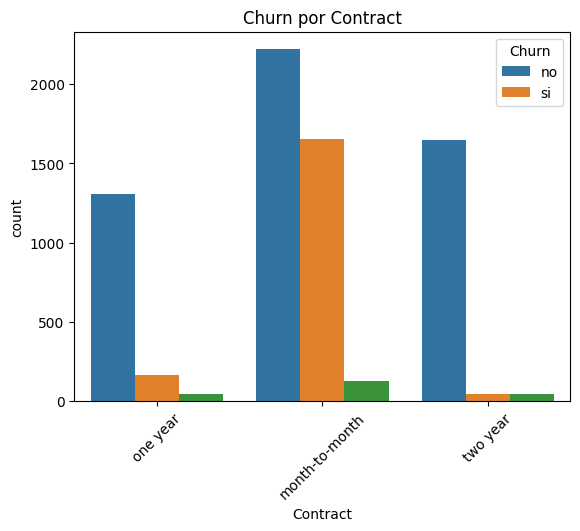

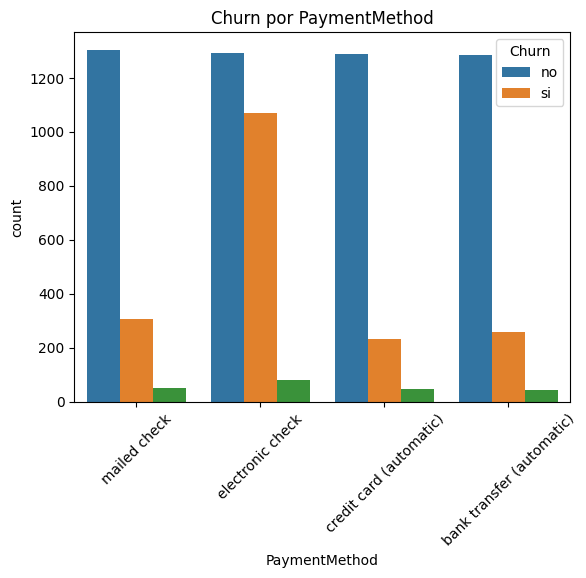

In [ ]:
#segun variables categoricas
categoricas = ['gender','Contract','PaymentMethod']

for col in categoricas:
    sns.countplot(x=col, hue='Churn', data=df_telecom)
    plt.title(f"Churn por {col}")
    plt.xticks(rotation=45)
    plt.show()



#📄Informe final

Las variables clave son:

Churn: Variable objetivo.

Tenure: permanencia del cliente.

MonthlyCharges / TotalCharges: Impacto económico en la decisión de baja.

Contract: Tipo de contrato influye en la probabilidad de churn.

InternetService, PhoneService, StreamingTV, StreamingMovies: Servicios contratados que pueden afectar la satisfacción.

PaymentMethod: Forma de pago, asociada a comodidad o fricción.

# Informe de Análisis de Evasión de Clientes (Churn)

## Introducción
El objetivo de este análisis es comprender los factores que influyen en la evasión de clientes (Churn) en la empresa TelecomX. La evasión representa un desafío estratégico, ya que impacta directamente en los ingresos y la sostenibilidad del negocio. Identificar patrones y variables asociadas al churn permite diseñar acciones para retener clientes y mejorar la experiencia de servicio.

## Limpieza y Tratamiento de Datos
- Se importaron los datos desde el archivo JSON proporcionado.
- Se normalizaron las estructuras anidadas (customer, phone, internet, account).
- Se verificaron valores ausentes, duplicados y errores de formato.
- Se aplicaron correcciones: normalización de strings, imputación de nulos en variables numéricas y eliminación de duplicados.

## Análisis Exploratorio de Datos
- **Análisis descriptivo:** Se calcularon métricas como media, mediana y desviación estándar para comprender la distribución de variables numéricas (`MonthlyCharges`, `TotalCharges`, `Tenure`).
- **Distribución de Churn:** Se visualizó la proporción de clientes que permanecieron frente a los que cancelaron, mostrando un desbalance moderado.
- **Variables categóricas:** Se analizaron género, tipo de contrato y método de pago en relación con Churn. Se observaron diferencias en la evasión según el tipo de contrato y método de pago.

## Conclusiones
- Promover métodos de pago automáticos para disminuir fricciones en la facturación.
- Diseñar estrategias de fidelización para clientes con bajo gasto mensual, como promociones o paquetes adicionales.
- Implementar campañas de retención dirigidas a clientes en los primeros meses de contrato, donde la evasión es más frecuente.

